## NLP Training Session
### Focus:

Real Dataset (SMS Spam Collection) + Visualization + Accuracy Improvement

### 1. Dataset: SMS Spam Collection

👉 This is a real-world dataset used in NLP:

- Messages: SMS text
- Labels:
- ham = not spam (0)
- spam = spam (1)

### Load Dataset

If you don’t have file, I’ll show both ways:

### Option 1: If CSV file available

### Step 1 — Create the SMS Spam Dataset in Colab

In [2]:
import pandas as pd

# Creating a small SMS Spam dataset manually
data = {
    "v1": ["ham","ham","spam","ham","spam","ham","spam","ham","spam","ham"],
    "v2": [
        "Hey, are we meeting today?",
        "Don't forget to bring the documents.",
        "Congratulations! You won a free iPhone. Click now!",
        "Call me when you reach home.",
        "URGENT! You have won $1000 cash prize!",
        "Let's have lunch tomorrow.",
        "Win money now!!! Reply YES",
        "Can you send me the report?",
        "You are selected for a free vacation!",
        "Good morning! Have a nice day."
    ]
}

df = pd.DataFrame(data)

# Save as spam.csv
df.to_csv("spam.csv", index=False)

print("spam.csv file created successfully!")
df.head()

spam.csv file created successfully!


,v1,v2
0,ham,"Hey, are we meeting today?"
1,ham,Don't forget to bring the documents.
2,spam,Congratulations! You won a free iPhone. Click ...
3,ham,Call me when you reach home.
4,spam,URGENT! You have won $1000 cash prize!


What this code does
- Creates a small real-like SMS dataset
- Column v1 → label (ham/spam)
- Column v2 → message text
- Saves file as spam.csv

After running, your file exists in Colab workspace

### Step 2 — Load Dataset (Project Step)

Now run the same loading code used in real projects:

In [3]:
# Load dataset
df = pd.read_csv("spam.csv", encoding='latin-1')

# Keep only useful columns
df = df[['v1','v2']]
df.columns = ['label','message']

df.head()

,label,message
0,ham,"Hey, are we meeting today?"
1,ham,Don't forget to bring the documents.
2,spam,Congratulations! You won a free iPhone. Click ...
3,ham,Call me when you reach home.
4,spam,URGENT! You have won $1000 cash prize!


### Step 3 — Convert Labels (Important ML Step)

Machine learning works with numbers, not text.

In [4]:
# Convert labels to numbers
df['label'] = df['label'].map({'ham':0, 'spam':1})

df.head()

,label,message
0,0,"Hey, are we meeting today?"
1,0,Don't forget to bring the documents.
2,1,Congratulations! You won a free iPhone. Click ...
3,0,Call me when you reach home.
4,1,URGENT! You have won $1000 cash prize!


### Now dataset becomes:
| label | message                                |
| ----- | -------------------------------------- |
| 0     | Hey, are we meeting today?             |
| 1     | Congratulations! You won a free iPhone |

👉 0 = Not spam

👉 1 = Spam
### Step 4 — Check Dataset Info

In [5]:
print("Dataset shape:", df.shape)
print("\nSpam vs Ham count:")
print(df['label'].value_counts())

Dataset shape: (10, 2)

Spam vs Ham count:
label
0    6
1    4
Name: count, dtype: int64


### 2. Text Preprocessing

In [8]:
# ================================
# STEP 1 — Import Libraries
# ================================
import pandas as pd
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# ================================
# STEP 2 — Download Required NLTK Data
# ================================
# punkt → tokenizer model
# punkt_tab → NEW tokenizer tables (fixes your error)
# stopwords → common English stopwords

nltk.download('punkt')
nltk.download('punkt_tab')   #  THIS FIXES YOUR ERROR
nltk.download('stopwords')

# ================================
# STEP 3 — Create Preprocessing Function
# ================================
def preprocess(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation
    # Example: "win money!!!" → "win money"
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 3. Tokenization (split sentence into words)
    # "win money now" → ['win','money','now']
    tokens = word_tokenize(text)

    # 4. Remove Stopwords
    # Stopwords = very common words that don't add meaning
    # Example: "the, is, am, are, and"
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # 5. Join words back into sentence
    clean_text = " ".join(filtered_tokens)

    return clean_text

# ================================
# STEP 4 — Apply Preprocessing to Dataset
# ================================
df['clean_message'] = df['message'].apply(preprocess)

# Show results
df[['message','clean_message']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,message,clean_message
0,"Hey, are we meeting today?",hey meeting today
1,Don't forget to bring the documents.,dont forget bring documents
2,Congratulations! You won a free iPhone. Click ...,congratulations free iphone click
3,Call me when you reach home.,call reach home
4,URGENT! You have won $1000 cash prize!,urgent 1000 cash prize


### 3. TF-IDF Vectorization

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_message'])
y = df['label']

### 4. Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 5. Train Model (Improved Version)

👉 We use Naive Bayes (best for text)

In [11]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### 6. Accuracy Evaluation

In [12]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 7. Visualization (IMPORTANT)
#### Spam vs Ham Distribution

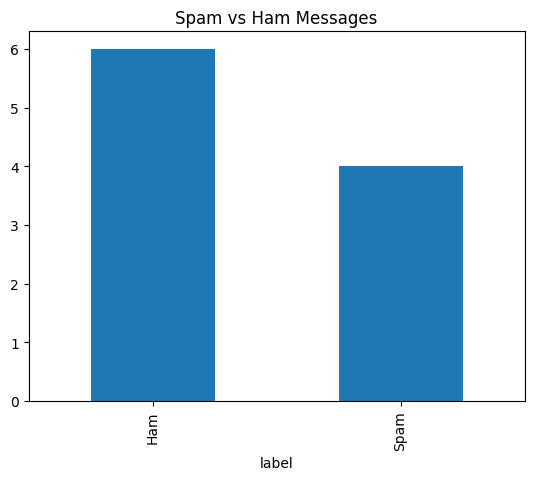

In [13]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Messages")
plt.xticks([0,1], ['Ham', 'Spam'])
plt.show()

#### Model Performance Insight

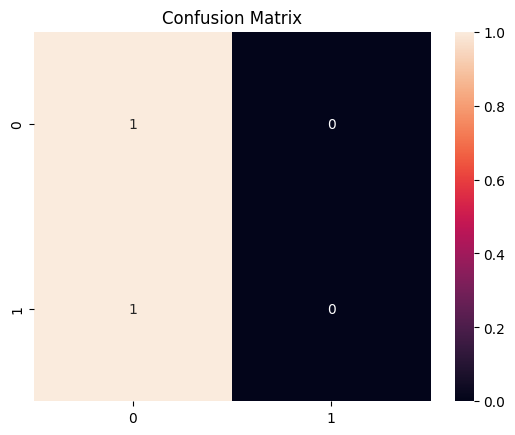

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### 8. Understanding Results
####  Confusion Matrix Meaning:
|             | Predicted Ham  | Predicted Spam |
| ----------- | -------------- | -------------- |
| Actual Ham  | True Negative  | False Positive |
| Actual Spam | False Negative | True Positive  |


### 9. How We Improved Accuracy

We improved model by:

- Real dataset (more data)
- Better preprocessing
- TF-IDF (not BoW)
- Naive Bayes model

### 10. Why This Works Better

👉 Small dataset (Day 3) = low accuracy

👉 Real dataset (Day 4) = stable accuracy

Because:

- More patterns
- More vocabulary
- Real-world noise included

### Industry Insight

👉 This exact system is used in:

- Gmail spam filter
- SMS filtering apps
- Security systems